In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [5]:
import sys

sys.path.append("../../")

from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.minimum_eigensolvers import SamplingVQE
from qiskit_ibm_runtime import Sampler
from qiskit.primitives import Sampler as LocalSampler
import matplotlib.pyplot as plt
import numpy as np
from qufold import (
    MiyazawaJerniganInteraction,
    Peptide,
    ProteinFoldingProblem,
    PenaltyParameters,
)
from qiskit.quantum_info import SparsePauliOp


In [6]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
 
service = QiskitRuntimeService()
backend = service.backend("ibm_cleveland")

pm= generate_preset_pass_manager(optimization_level=3, backend=backend)

In [7]:
def build_pf(main_seq: str):
    """Builds the protein folding problem for the given sequence."""
    # Define the interaction
    side_chains = [""] * len(main_seq)

    mj_interaction = MiyazawaJerniganInteraction()

    penalty_back = 10
    penalty_chiral = 10
    penalty_1 = 10

    penalty_terms = PenaltyParameters(penalty_chiral, penalty_back, penalty_1)

    peptide = Peptide(main_seq, side_chains)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [8]:
main_chain = "YYDPETGTWY" # 10 AA chingolin
pf = build_pf(main_chain) #creates the PF problem instance

In [9]:
qubit_op = pf.qubit_op() #creates the problem Hamiltonian

In [10]:
from qiskit_ibm_runtime import Session, Options, QiskitRuntimeService


options = Options(
    execution={"shots": 5000},
    resilience_level=0,
    transpilation={"skip_transpilation": False},
    optimization_level=3,
    # environment={"job_tags": [f"batch_{i}"]},
)

def run_vqe(qubit_op):
    # set classical optimizer
    optimizer = COBYLA(maxiter=100)

    # set variational ansatz
    ansatz = EfficientSU2(num_qubits=qubit_op.num_qubits,reps=1)
    ansatz_t = pm.run(ansatz)
    print(ansatz_t.num_qubits)
    qubit_op_t = qubit_op.apply_layout(ansatz_t.layout)
    print(qubit_op_t)
    counts = []
    values = []

    def store_intermediate_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)
    with Session(backend=backend):
        vqe = SamplingVQE(
            Sampler(options=options),
            ansatz=ansatz_t,
            optimizer=optimizer,
            aggregation=0.1,
            callback=store_intermediate_result)
    
        raw_result = vqe.compute_minimum_eigenvalue(qubit_op_t)

    return raw_result, counts, values

In [11]:
raw_result, counts, values = run_vqe(qubit_op)

127
SparsePauliOp(['...'],
              coeffs=[ 1.0128553e+04+0.j,  1.8800000e+03+0.j, -8.5250000e+02+0.j,
  8.5250000e+02+0.j, -9.4750000e+02+0.j, -9.4750000e+02+0.j,
 -9.4750000e+02+0.j, -9.4750000e+02+0.j, -9.4750000e+02+0.j,
 -9.4750000e+02+0.j, -8.5250000e+02+0.j, -8.5250000e+02+0.j,
 -8.5250000e+02+0.j, -6.2250000e+02+0.j, -6.2250000e+02+0.j,
 -6.2250000e+02+0.j, -4.0000000e+02+0.j, -4.0000000e+02+0.j,
 -4.0000000e+02+0.j,  1.0275000e+03+0.j, -1.8900000e+03+0.j,
 -1.0325000e+03+0.j,  8.0500000e+02+0.j,  8.5750000e+02+0.j,
 -8.5750000e+02+0.j, -9.0484950e+02+0.j, -2.9500000e+02+0.j,
 -1.9750000e+02+0.j,  3.0250000e+02+0.j,  2.0250000e+02+0.j,
  1.0000000e+02+0.j,  1.0000000e+02+0.j,  1.0000000e+02+0.j,
 -2.0000000e+02+0.j,  9.7500000e+01+0.j, -9.7500000e+01+0.j,
 -1.0000000e+02+0.j,  1.0000000e+02+0.j,  2.2250000e+02+0.j,
 -2.2250000e+02+0.j,  2.5000000e+00+0.j, -2.5000000e+00+0.j,
  1.5850000e+03+0.j,  8.2750000e+02+0.j,  8.5000000e+02+0.j,
  8.5000000e+02+0.j,  8.5000000e+02+0

c:\Users\8J6010897\AppData\Local\anaconda3\envs\protein_new\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\8J6010897\AppData\Local\anaconda3\envs\protein_new\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


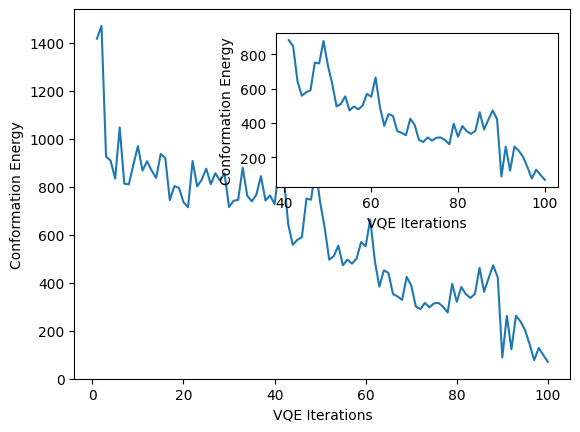

In [12]:
fig = plt.figure()

plt.plot(counts, values)
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")

fig.add_axes([0.44, 0.51, 0.44, 0.32])

plt.plot(counts[40:], values[40:])
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")
plt.show()

The bitstring representing the shape of the protein during optimization is:  0000000000000000000000000000000000000001000000000000100000100001100000000000000000000010001000000010000110001010001110100000000
The expanded expression is: 000000000000000000000000000000000000000100000000000010000010000110000000000000000000001000100000001000011___________________________________0_________0_______0_1_______0_1_____0_0_0__________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________111010000000_0____
The folded protein's main sequence of turns is: [1, 0, 1, 0, 0, 0, 1, 1, 3]
and the side turn sequences are: [None, None, None, None, None, None, None, None, None, None]


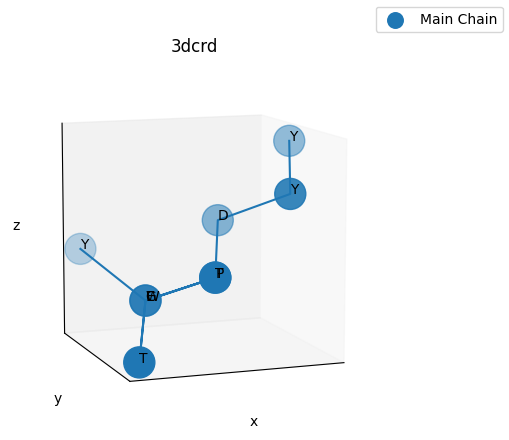

In [15]:
result = pf.interpret_new(raw_result=raw_result)
print(
    "The bitstring representing the shape of the protein during optimization is: ",
    result.turn_sequence,
)
print("The expanded expression is:", result.get_result_binary_vector())

##

print(f"The folded protein's main sequence of turns is: {result.protein_shape_decoder.main_turns}")
print(f"and the side turn sequences are: {result.protein_shape_decoder.side_turns}")

fig = result.get_figure(title="3dcrd", ticks=False, grid=True)
fig.get_axes()[0].view_init(10, 70)

In [17]:
# multiply numerical values by 3.8
xyz_coords = result.protein_shape_file_gen.get_xyz_data()
for i in range(len(xyz_coords)):
    for j in range(1, len(xyz_coords[i])):
        xyz_coords[i][j] = float(xyz_coords[i][j]) * 3.8

print(xyz_coords)

[['Y' '0.0' '0.0' '0.0']
 ['Y' '2.193931022920578' '2.193931022920578' '-2.193931022920578']
 ['D' '4.387862045841156' '0.0' '-4.387862045841156']
 ['P' '6.581793068761734' '2.193931022920578' '-6.581793068761734']
 ['E' '8.775724091682312' '0.0' '-8.775724091682312']
 ['T' '6.581793068761734' '2.193931022920578' '-6.581793068761734']
 ['G' '8.775724091682312' '0.0' '-8.775724091682312']
 ['T' '10.96965511460289' '2.193931022920578' '-10.96965511460289']
 ['W' '8.775724091682312' '0.0' '-8.775724091682312']
 ['Y' '10.96965511460289' '-2.193931022920578' '-6.581793068761734']]
